In [1]:
import pandas as pd, numpy as np, os
from db_queries import get_population, get_covariate_estimates, get_outputs, get_ids
import vivarium.artifact as art
from get_draws.api import get_draws
import matplotlib.pyplot as plt

from lsff_utils import paths

In [2]:
location = 'india'
vehicle = 'rice'
model_number = paths.MODEL_NUMBER  # the archived iteration to check; set explicitly to read an older one

l = get_ids('location')
location_id = l.loc[l.location_name==location.title()].location_id.values[0]

# Resolved from the archive layout; the run is the one archive_last_run.sh published.
results_dir = paths.latest_results(
    paths.archive_root(paths.MATERNAL_RESULTS_ROOT, model_number), location, vehicle
)
artifact_dir = paths.artifact_path(
    paths.archive_root(paths.MATERNAL_ARTIFACT_ROOT, model_number), location, vehicle
)
print(f"{model_number} {vehicle}/{location}\n  results:  {results_dir}\n  artifact: {artifact_dir}")

model1.2.4 rice/india
  results:  /mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.2.4/maternal/rice/india/2026_09_09_21_08_10/results
  artifact: /mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.2.4/maternal/rice/india.hdf


# First, load artifact

In [3]:
art = art.Artifact(artifact_dir, filter_terms=['sex==Female','age_start>5','age_end<=60'])

In [4]:
def add_age_group(data):
    data = data.copy() if 'age_start' in data.columns else data.reset_index()
    data['age_group'] = (data.age_start.astype(int).astype(str)
                         + '_to_' + (data.age_end.astype(int) - 1).astype(str))
    return data

In [5]:
art.keys

['metadata.keyspace',
 'metadata.locations',
 'population.location',
 'population.structure',
 'population.age_bins',
 'population.demographic_dimensions',
 'population.theoretical_minimum_risk_life_expectancy',
 'population.infant_male_percentage',
 'population.wealth_quintile_probabilities',
 'cause.all_causes.cause_specific_mortality_rate',
 'vehicle.name',
 'covariate.age_specific_fertility_rate.estimate',
 'covariate.stillbirth_28_weeks_to_live_birth_ratio.estimate',
 'cause.maternal_abortion_and_miscarriage.raw_incidence_rate',
 'cause.ectopic_pregnancy.raw_incidence_rate',
 'risk_factor.low_birth_weight_and_short_gestation.exposure',
 'risk_factor.low_birth_weight_and_short_gestation.distribution',
 'risk_factor.low_birth_weight_and_short_gestation.categories',
 'cause.maternal_disorders.raw_incidence_rate',
 'cause.maternal_disorders.incident_probability',
 'cause.maternal_disorders.cause_specific_mortality_rate',
 'cause.maternal_disorders.mortality_probability',
 'cause.mater

In [6]:
# load up pregnancy incidence
# equations found here: https://vivarium-research.readthedocs.io/en/latest/models/other_models/pregnancy/gbd_2021_closed_cohort/index.html
asfr = art.load('covariate.age_specific_fertility_rate.estimate')
sbr = art.load('covariate.stillbirth_28_weeks_to_live_birth_ratio.estimate')   # GBD 2023 split the covariate into 20/28-week variants; model 1.1 carries the 28-week one
inc_mis = art.load('cause.maternal_abortion_and_miscarriage.raw_incidence_rate')
inc_ect = art.load('cause.ectopic_pregnancy.raw_incidence_rate')
art_preg_inc = (asfr 
               + asfr * sbr.value.values[0]
               + inc_mis 
               + inc_ect)
art_preg_inc.head()

draw_0
sex    age_start age_end year_start year_end          
Female 10.0      15.0    2023       2024      0.000514
       15.0      20.0    2023       2024      0.010748
       20.0      25.0    2023       2024      0.108000
       25.0      30.0    2023       2024      0.139357
       30.0      35.0    2023       2024      0.088701

In [7]:
# load artifact MD data
art_md_mort = art.load('cause.maternal_disorders.cause_specific_mortality_rate')
art_mort_frac = art_md_mort / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_mort_frac.head()

draw_0
sex    age_start age_end year_start year_end            
Female 10.0      15.0    2023       2024       50.266103
       15.0      20.0    2023       2024      339.028792
       20.0      25.0    2023       2024       83.486863
       25.0      30.0    2023       2024       69.943640
       30.0      35.0    2023       2024       96.758831

In [8]:
# load artifact MD data
art_md_inc = art.load('cause.maternal_disorders.raw_incidence_rate')
art_mh_inc = art.load('cause.maternal_hemorrhage.raw_incidence_rate')
art_inc_frac = art_md_inc / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_mh_frac = art_mh_inc / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_inc_frac#.head()

draw_0
sex    age_start age_end year_start year_end              
Female 10.0      15.0    2023       2024      58073.149914
       15.0      20.0    2023       2024      48198.996514
       20.0      25.0    2023       2024      37937.690088
       25.0      30.0    2023       2024      40045.672896
       30.0      35.0    2023       2024      46921.105576
       35.0      40.0    2023       2024      55362.028945
       40.0      45.0    2023       2024      66698.004059
       45.0      50.0    2023       2024      81971.866621
       50.0      55.0    2023       2024      97168.530314
       55.0      60.0    2023       2024               NaN

In [9]:
art_mh_frac
    # zeros for 50-55 year olds

draw_0
sex    age_start age_end year_start year_end             
Female 10.0      15.0    2023       2024      4248.997990
       15.0      20.0    2023       2024      4257.343754
       20.0      25.0    2023       2024      1550.884537
       25.0      30.0    2023       2024      1291.020641
       30.0      35.0    2023       2024      1282.534220
       35.0      40.0    2023       2024      1660.821264
       40.0      45.0    2023       2024      2049.543388
       45.0      50.0    2023       2024      3200.954614
       50.0      55.0    2023       2024      3409.176449
       55.0      60.0    2023       2024              NaN

# Now, load sim data

In [10]:
deaths = pd.read_parquet(paths.measure_path(results_dir, "deaths"))
deaths = deaths.loc[deaths.entity == 'maternal_disorders']
deaths.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
5,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,1,baseline,0,141,0.0
6,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,2,baseline,0,141,0.0
7,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,3,baseline,0,141,0.0
8,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,4,baseline,0,141,0.0
9,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,5,baseline,0,141,0.0


In [11]:
# assert deaths.entity.unique() == ['maternal_disorders'], "deaths data has more causes than maternal disorders which is the only expected cause"

In [12]:
md_inc = pd.read_parquet(paths.measure_path(results_dir, "transition_count_maternal_disorders"))
md_inc = md_inc.loc[md_inc.sub_entity=='susceptible_to_maternal_disorders_to_maternal_disorders']
md_inc = (md_inc.groupby(['scenario','input_draw','age_group'])['value'].sum()
          + deaths.groupby(['scenario','input_draw','age_group'])['value'].sum()
         ).reset_index() 
# note that incident cases are only counted among surviving simulants, so we add in deaths here
md_inc.head()

,scenario,input_draw,age_group,value
0,baseline,0,10_to_14,4542.0
1,baseline,0,15_to_19,91853.0
2,baseline,0,20_to_24,910172.0
3,baseline,0,25_to_29,1387387.0
4,baseline,0,30_to_34,1049026.0


In [13]:
mh_inc = pd.read_parquet(paths.measure_path(results_dir, "transition_count_maternal_hemorrhage"))
mh_inc = mh_inc.loc[mh_inc.sub_entity=='susceptible_to_maternal_hemorrhage_to_maternal_hemorrhage']
mh_inc.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,1,baseline,0,141,0.0
1,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,2,baseline,0,141,0.0
2,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,3,baseline,0,141,0.0
3,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,4,baseline,0,141,0.0
4,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,5,baseline,0,141,0.0


In [14]:
births = pd.read_parquet(paths.measure_path(results_dir, "transition_count_pregnancy"))
births = births.loc[births.sub_entity=='pregnant_to_parturition']
# add in deaths because they are not getting tracked in the parturition transition counts
births = (births.groupby(['scenario','input_draw','age_group'])['value'].sum()
          + deaths.groupby(['scenario','input_draw','age_group'])['value'].sum()).reset_index()
births.head()

,scenario,input_draw,age_group,value
0,baseline,0,10_to_14,7803.0
1,baseline,0,15_to_19,198728.0
2,baseline,0,20_to_24,2472761.0
3,baseline,0,25_to_29,3582183.0
4,baseline,0,30_to_34,2338787.0


In [15]:
births.loc[births.scenario=='baseline'].groupby('input_draw')['value'].sum().unique()

array([10000000.])

In [16]:
n_simulants_per_draw = 10_000_000  # model 1.2.4 archived runs use 200 seeds x 50k simulants (was 500_000 = 10 seeds through model 1.1.1)
assert births.loc[births.scenario=='baseline'].groupby('input_draw')['value'].sum().unique() == [n_simulants_per_draw], "Number of births does not match expected number of simulants"

In [17]:
cols = ['scenario','input_draw','age_group']
mort_frac_births = ((deaths.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                    .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
inc_frac_births = ((md_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                    .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
mh_frac_births = ((mh_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                     .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
mort_frac_births.head()

/tmp/ipykernel_3893914/3074800288.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mort_frac_births = ((deaths.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)


/tmp/ipykernel_3893914/3074800288.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mh_frac_births = ((mh_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)


count        mean  std         min        2.5%  \
scenario age_group                                                   
baseline 10_to_14     1.0   89.709086  NaN   89.709086   89.709086   
         15_to_19     1.0  308.965018  NaN  308.965018  308.965018   
         20_to_24     1.0   82.256231  NaN   82.256231   82.256231   
         25_to_29     1.0   70.292333  NaN   70.292333   70.292333   
         30_to_34     1.0   92.227296  NaN   92.227296   92.227296   

                           50%       97.5%         max  
scenario age_group                                      
baseline 10_to_14    89.709086   89.709086   89.709086  
         15_to_19   308.965018  308.965018  308.965018  
         20_to_24    82.256231   82.256231   82.256231  
         25_to_29    70.292333   70.292333   70.292333  
         30_to_34    92.227296   92.227296   92.227296

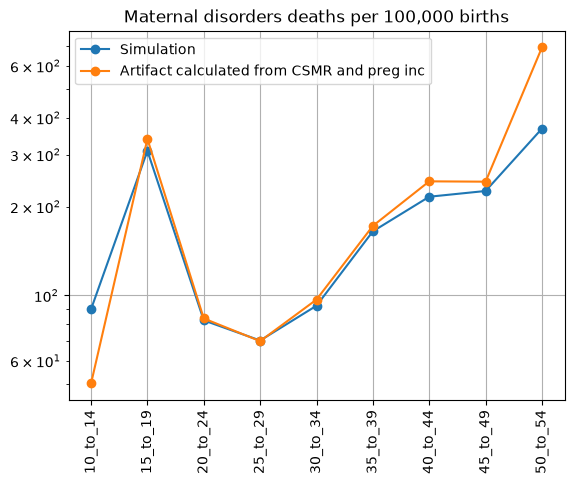

In [18]:
sim = mort_frac_births.reset_index().loc[mort_frac_births.reset_index().scenario
                                        =='baseline']

plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_mort_frac[[c for c in art_mort_frac.columns if int(c.split('_')[1]) in deaths.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact calculated from CSMR and preg inc')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal disorders deaths per 100,000 births')
plt.semilogy()
plt.show()
# a little off in our edge age groups but otherwise looking good

In [19]:
deaths = deaths.loc[deaths.entity=='maternal_disorders']
deaths = deaths.groupby(['age_group','scenario','input_draw'])['value'].sum().reset_index()
deaths = deaths.groupby(['age_group','scenario'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
deaths.head()

,age_group,scenario,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,baseline,1.0,7.0,NaN,7.0,7.0,7.0,7.0,7.0
1,10_to_14,intervention,1.0,7.0,NaN,7.0,7.0,7.0,7.0,7.0
2,10_to_14,zero,1.0,7.0,NaN,7.0,7.0,7.0,7.0,7.0
3,15_to_19,baseline,1.0,614.0,NaN,614.0,614.0,614.0,614.0,614.0
4,15_to_19,intervention,1.0,614.0,NaN,614.0,614.0,614.0,614.0,614.0


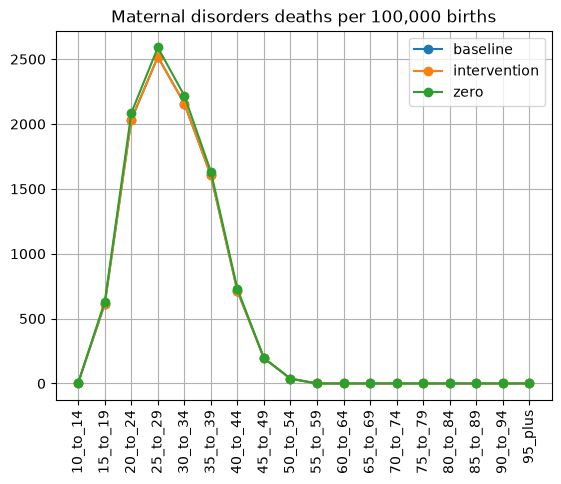

In [20]:
for scenario in deaths.scenario.unique(): 
    sim = deaths.loc[deaths.scenario==scenario]
    plt.plot(sim.age_group, sim['mean'], marker='o', label=scenario)
    #plt.fill_between(sim.age, sim['2.5%'], sim['97.5%'], alpha=0.2)

plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal disorders deaths per 100,000 births')
#plt.semilogy()
plt.show()

# ok this looks as expected!
# zero coverage should be the highest, followed by baseline
# then the remaining scenarios should all overlap below baseline

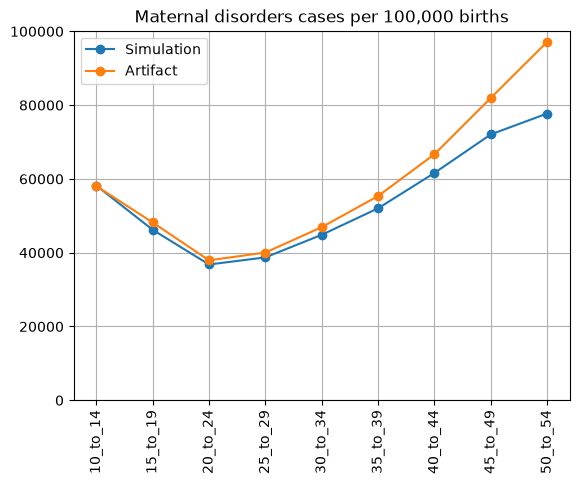

In [21]:
sim = inc_frac_births.reset_index().loc[inc_frac_births.reset_index().scenario
                                        =='baseline']
plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_inc_frac[[c for c in art_inc_frac.columns if int(c.split('_')[1]) in mh_inc.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.ylim(ymin=0)
plt.title('Maternal disorders cases per 100,000 births')
plt.show()

# it's looking a little high... what if we don't add in deaths?

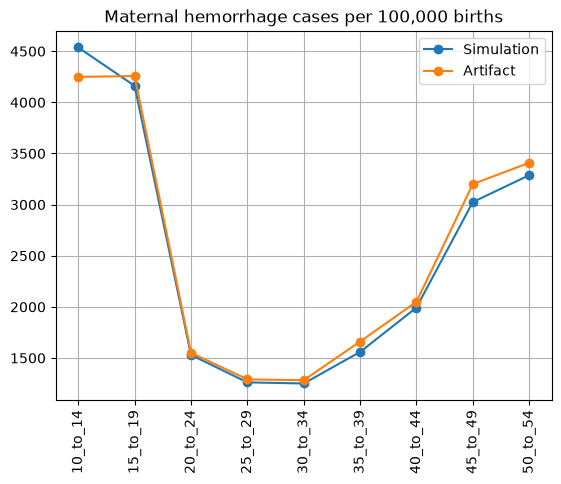

In [22]:
sim = mh_frac_births.reset_index().loc[mh_frac_births.reset_index().scenario
                                        =='baseline']

plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_mh_frac#[[c for c in art_mh_frac.columns if int(c.split('_')[1]) in mh_inc.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal hemorrhage cases per 100,000 births')
plt.show()

In [23]:
preg_inc = art_preg_inc.reset_index()
preg_inc['age_group'] = (preg_inc.age_start.astype(int).astype(str) + '_to_' + (preg_inc.age_end.astype(int)-1).astype(str))
preg_inc = preg_inc.set_index('age_group')[[c for c in preg_inc.columns if 'draw' in c]]
preg_inc = preg_inc.stack().reset_index().rename(columns={'level_1':'input_draw',0:'value'})
preg_inc['input_draw'] = preg_inc.input_draw.str.split('_', expand=True)[1].astype(int)
preg_inc = preg_inc.set_index(['age_group','input_draw'])
preg_inc

,,value
age_group,input_draw,
10_to_14,0,0.000514
15_to_19,0,0.010748
20_to_24,0,0.108000
25_to_29,0,0.139357
30_to_34,0,0.088701
35_to_39,0,0.037751
40_to_44,0,0.014498
45_to_49,0,0.004212
50_to_54,0,0.000512


In [24]:
# what about YLDs?
ylds = pd.read_parquet(paths.measure_path(results_dir, "ylds"))
ylds_per_birth = (ylds.groupby(cols + ['entity']).sum() / births.groupby(cols).sum())[['value']]
yld_rate = (ylds_per_birth.reset_index().set_index(['age_group','input_draw','scenario','entity']) * preg_inc).dropna()
yld_rate = yld_rate.groupby([c for c in cols if c != 'input_draw'] + ['entity'])['value'].describe(percentiles=[0.025,0.975])
ylds

/tmp/ipykernel_3893914/2804482910.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ylds_per_birth = (ylds.groupby(cols + ['entity']).sum() / births.groupby(cols).sum())[['value']]


,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,ylds,cause,pregnancy,pregnant,10_to_14,invalid,1,baseline,0,141,0.0
1,ylds,cause,pregnancy,parturition,10_to_14,invalid,1,baseline,0,141,0.0
2,ylds,cause,pregnancy,postpartum,10_to_14,invalid,1,baseline,0,141,0.0
3,ylds,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,1,baseline,0,141,0.0
4,ylds,cause,maternal_hemorrhage,maternal_hemorrhage,10_to_14,invalid,1,baseline,0,141,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1889995,ylds,cause,pregnancy,postpartum,95_plus,severe,5,zero,0,129,0.0
1889996,ylds,cause,maternal_disorders,maternal_disorders,95_plus,severe,5,zero,0,129,0.0
1889997,ylds,cause,maternal_hemorrhage,maternal_hemorrhage,95_plus,severe,5,zero,0,129,0.0
1889998,ylds,cause,all_causes,all_causes,95_plus,severe,5,zero,0,129,0.0


In [25]:
YEAR_START = 2023  # GBD 2023 (release 16), matching the model's data vintage 
gbd_ylds = get_draws(release_id=16,
                    year_id=YEAR_START, 
                    source='como',
                    gbd_id_type='cause_id',
                    gbd_id=366,
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
gbd_ylds

/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


,year_id,sex_id,age_group_id,measure_id,cause_id,draw_0,draw_1,draw_2,draw_3,draw_4,...,draw_243,draw_244,draw_245,draw_246,draw_247,draw_248,draw_249,location_id,metric_id,version_id
0,2023,2,7,3,366,0.000001,0.000001,0.000003,0.000004,0.000001,...,0.000002,0.000002,0.000003,0.000002,0.000002,0.000002,0.000002,163,3,1762
1,2023,2,8,3,366,0.000041,0.000064,0.000058,0.000069,0.000028,...,0.000043,0.000091,0.000103,0.000046,0.000044,0.000059,0.000042,163,3,1762
2,2023,2,9,3,366,0.000357,0.000379,0.000439,0.000452,0.000320,...,0.000373,0.000630,0.000501,0.000431,0.000357,0.000431,0.000354,163,3,1762
3,2023,2,10,3,366,0.000746,0.000550,0.000650,0.000831,0.000710,...,0.000870,0.001081,0.000859,0.000793,0.000659,0.000792,0.000683,163,3,1762
4,2023,2,11,3,366,0.000995,0.000630,0.000704,0.001051,0.000934,...,0.001231,0.001209,0.001145,0.000947,0.000819,0.001086,0.000758,163,3,1762
5,2023,2,12,3,366,0.000805,0.000492,0.000606,0.000823,0.000770,...,0.000920,0.000874,0.000833,0.000745,0.000698,0.000898,0.000558,163,3,1762
6,2023,2,13,3,366,0.000532,0.000427,0.000508,0.000491,0.000566,...,0.000599,0.000628,0.000593,0.000595,0.000581,0.000600,0.000395,163,3,1762
7,2023,2,14,3,366,0.000313,0.000318,0.000329,0.000297,0.000383,...,0.000423,0.000447,0.000340,0.000389,0.000406,0.000385,0.000243,163,3,1762
8,2023,2,15,3,366,0.000202,0.000211,0.000198,0.000170,0.000214,...,0.000293,0.000224,0.000183,0.000184,0.000232,0.000229,0.000156,163,3,1762


In [26]:
# MD anemia YLDs
from db_queries import get_ids
x = get_draws(release_id=16,
                    year_id=YEAR_START,
                    source='como',
                    gbd_id_type='sequela_id',
                    gbd_id=[182,183,184],
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
x = x.merge(get_ids('age_group'), on='age_group_id')
x['age_start'] = x.age_group_name.str.split(' to ', expand=True)[0].astype(float)
x['age_end'] = x.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
x['sex'] = 'Female'
x = x.groupby(['sex','age_start','age_end',])[[c for c in x.columns if 'draw' in c]].sum()
x

/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


draw_0        draw_1        draw_2  \
sex    age_start age_end                                             
Female 10.0      15.0     2.360774e-07  5.332088e-08  9.650409e-08   
       15.0      20.0     2.670109e-06  1.255016e-06  1.438606e-06   
       20.0      25.0     9.399122e-06  6.607579e-06  5.682186e-06   
       25.0      30.0     6.379211e-06  4.767862e-06  7.117953e-06   
       30.0      35.0     3.170818e-06  2.099087e-06  4.329955e-06   
       35.0      40.0     1.739293e-06  1.114499e-06  2.181263e-06   
       40.0      45.0     9.186732e-07  5.970067e-07  8.817924e-07   
       45.0      50.0     4.542283e-07  2.907731e-07  4.420769e-07   
       50.0      55.0     7.358902e-08  4.385999e-08  6.115519e-08   

                                draw_3        draw_4        draw_5  \
sex    age_start age_end                                             
Female 10.0      15.0     2.047876e-07  6.599035e-08  2.001667e-08   
       15.0      20.0     5.146312e-06  1.698593e-06  8.681456e-07   
       20.0      25.0     1.901112e-05  6.284975e-06  1.809329e-06   
       25.0      30.0     1.436218e-05  9.033722e-06  2.130342e-06   
       30.0      35.0     7.152547e-06  5.159769e-06  1.678923e-06   
       35.0      40.0     3.971592e-06  2.016619e-06  9.515543e-07   
       40.0      45.0     1.634061e-06  9.903306e-07  5.333403e-07   
       45.0      50.0     7.479293e-07  5.039335e-07  1.928341e-07   
       50.0      55.0     1.301193e-07  5.942301e-08  1.934818e-08   

                                draw_6        draw_7        draw_8  \
sex    age_start age_end                                             
Female 10.0      15.0     3.207876e-08  8.864488e-08  1.457890e-08   
       15.0      20.0     3.772144e-07  1.939206e-06  3.854608e-07   
       20.0      25.0     1.699774e-06  5.855966e-06  1.075553e-06   
       25.0      30.0     1.421532e-06  7.017193e-06  1.069387e-06   
       30.0      35.0     9.189785e-07  4.700372e-06  5.886627e-07   
       35.0      40.0     4.305357e-07  3.149872e-06  3.252331e-07   
       40.0      45.0     2.305862e-07  1.107741e-06  1.789902e-07   
       45.0      50.0     1.110123e-07  3.522640e-07  8.080039e-08   
       50.0      55.0     2.033899e-08  5.847548e-08  1.019280e-08   

                                draw_9  ...      draw_240      draw_241  \
sex    age_start age_end                ...                               
Female 10.0      15.0     8.811969e-08  ...  9.406783e-08  1.316392e-07   
       15.0      20.0     2.530935e-06  ...  1.918848e-06  9.591050e-07   
       20.0      25.0     6.905642e-06  ...  6.428507e-06  3.263618e-06   
       25.0      30.0     7.319551e-06  ...  7.639133e-06  5.170240e-06   
       30.0      35.0     4.980923e-06  ...  4.763122e-06  5.040061e-06   
       35.0      40.0     3.028657e-06  ...  2.205246e-06  2.725382e-06   
       40.0      45.0     1.107888e-06  ...  1.015682e-06  1.393618e-06   
       45.0      50.0     4.498058e-07  ...  4.905822e-07  6.256808e-07   
       50.0      55.0     6.022226e-08  ...  6.280785e-08  6.910628e-08   

                              draw_242      draw_243      draw_244  \
sex    age_start age_end                                             
Female 10.0      15.0     1.836419e-07  4.712984e-08  4.768622e-08   
       15.0      20.0     1.042202e-06  6.842339e-07  1.116941e-06   
       20.0      25.0     4.646901e-06  2.061693e-06  5.543156e-06   
       25.0      30.0     7.380042e-06  2.244418e-06  3.978632e-06   
       30.0      35.0     5.185640e-06  1.119961e-06  2.094296e-06   
       35.0      40.0     1.251798e-06  8.621839e-07  1.188672e-06   
       40.0      45.0     5.453786e-07  4.379329e-07  7.099570e-07   
       45.0      50.0     3.256820e-07  2.120660e-07  4.365920e-07   
       50.0      55.0     5.063015e-08  3.125207e-08  4.408618e-08   

                              draw_245      draw_246      draw_247  \
sex    age_start age_end                            

In [27]:
# MD YLDs prepped
y = gbd_ylds.merge(get_ids('age_group'), on='age_group_id')
y['age_start'] = y.age_group_name.str.split(' to ', expand=True)[0].astype(float)
y['age_end'] = y.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
y['sex'] = 'Female'
y = y.set_index(['sex','age_start','age_end'])[[c for c in y.columns if 'draw' in c]]
y

draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                     
Female 10.0      15.0     0.000001  0.000001  0.000003  0.000004  0.000001   
       15.0      20.0     0.000041  0.000064  0.000058  0.000069  0.000028   
       20.0      25.0     0.000357  0.000379  0.000439  0.000452  0.000320   
       25.0      30.0     0.000746  0.000550  0.000650  0.000831  0.000710   
       30.0      35.0     0.000995  0.000630  0.000704  0.001051  0.000934   
       35.0      40.0     0.000805  0.000492  0.000606  0.000823  0.000770   
       40.0      45.0     0.000532  0.000427  0.000508  0.000491  0.000566   
       45.0      50.0     0.000313  0.000318  0.000329  0.000297  0.000383   
       50.0      55.0     0.000202  0.000211  0.000198  0.000170  0.000214   

                            draw_5    draw_6    draw_7    draw_8    draw_9  \
sex    age_start age_end                                                     
Female 10.0      15.0     0.000002  0.000001  0.000002  0.000001  0.000002   
       15.0      20.0     0.000046  0.000037  0.000060  0.000064  0.000042   
       20.0      25.0     0.000361  0.000270  0.000448  0.000294  0.000396   
       25.0      30.0     0.000840  0.000493  0.000819  0.000565  0.000760   
       30.0      35.0     0.001320  0.000628  0.000920  0.000781  0.000898   
       35.0      40.0     0.000947  0.000547  0.000668  0.000744  0.000631   
       40.0      45.0     0.000552  0.000434  0.000471  0.000512  0.000367   
       45.0      50.0     0.000290  0.000294  0.000282  0.000283  0.000231   
       50.0      55.0     0.000172  0.000157  0.000166  0.000171  0.000127   

                          ...  draw_240  draw_241  draw_242  draw_243  \
sex    age_start age_end  ...                                           
Female 10.0      15.0     ...  0.000002  0.000003  0.000002  0.000002   
       15.0      20.0     ...  0.000043  0.000061  0.000070  0.000043   
       20.0      25.0     ...  0.000440  0.000371  0.000491  0.000373   
       25.0      30.0     ...  0.000820  0.000676  0.000945  0.000870   
       30.0      35.0     ...  0.001161  0.000801  0.001133  0.001231   
       35.0      40.0     ...  0.001046  0.000677  0.000935  0.000920   
       40.0      45.0     ...  0.000761  0.000429  0.000634  0.000599   
       45.0      50.0     ...  0.000538  0.000300  0.000456  0.000423   
       50.0      55.0     ...  0.000268  0.000170  0.000297  0.000293   

                          draw_244  draw_245  draw_246  draw_247  draw_248  \
sex    age_start age_end                                                     
Female 10.0      15.0     0.000002  0.000003  0.000002  0.000002  0.000002   
       15.0      20.0     0.000091  0.000103  0.000046  0.000044  0.000059   
       20.0      25.0     0.000630  0.000501  0.000431  0.000357  0.000431   
       25.0      30.0     0.001081  0.000859  0.000793  0.000659  0.000792   
       30.0      35.0     0.001209  0.001145  0.000947  0.000819  0.001086   
       35.0      40.0     0.000874  0.000833  0.000745  0.000698  0.000898   
       40.0      45.0     0.000628  0.000593  0.000595  0.000581  0.000600   
       45.0      50.0     0.000447  0.000340  0.000389  0.000406  0.000385   
       50.0      55.0     0.000224  0.000183  0.000184  0.000232  0.000229   

                          draw_249  
sex    age_start age_end            
Female 10.0      15.0     0.000002  
       15.0      20.0     0.000042  
       20.0      25.0     0.000354  
       25.0      30.0     0.000683  
       30.0      35.0     0.000758  
       35.0      40.0     0.000558  
       40.0      45.0     0.000395  
       45.0      50.0     0.000243  
       50.0      55.0     0.000156  

[9 rows x 250 columns]

In [28]:
from db_queries import get_ids
g = y - x
g = g.reset_index().set_index(['age_start'])[[c for c in g.columns if 'draw' in c
                                and int(c.split('_')[1]) in ylds.input_draw.unique()]]
g = g.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
g

,age_start,count,mean,std,min,2.5%,50%,97.5%,max
0,10.0,1.0,0.000001,NaN,0.000001,0.000001,0.000001,0.000001,0.000001
1,15.0,1.0,0.000039,NaN,0.000039,0.000039,0.000039,0.000039,0.000039
2,20.0,1.0,0.000348,NaN,0.000348,0.000348,0.000348,0.000348,0.000348
3,25.0,1.0,0.000739,NaN,0.000739,0.000739,0.000739,0.000739,0.000739
4,30.0,1.0,0.000992,NaN,0.000992,0.000992,0.000992,0.000992,0.000992
5,35.0,1.0,0.000803,NaN,0.000803,0.000803,0.000803,0.000803,0.000803
6,40.0,1.0,0.000531,NaN,0.000531,0.000531,0.000531,0.000531,0.000531
7,45.0,1.0,0.000313,NaN,0.000313,0.000313,0.000313,0.000313,0.000313
8,50.0,1.0,0.000202,NaN,0.000202,0.000202,0.000202,0.000202,0.000202


In [29]:
md_ylds = yld_rate.copy().reset_index()
# md_ylds = md_ylds.loc[(md_ylds.entity=='maternal_disorders')
#                      &(md_ylds.scenario=='baseline')]
md_ylds

,scenario,age_group,entity,count,mean,std,min,2.5%,50%,97.5%,max
0,baseline,10_to_14,all_causes,1.0,0.000016,NaN,0.000016,0.000016,0.000016,0.000016,0.000016
1,baseline,10_to_14,anemia,1.0,0.000014,NaN,0.000014,0.000014,0.000014,0.000014,0.000014
2,baseline,10_to_14,maternal_disorders,1.0,0.000002,NaN,0.000002,0.000002,0.000002,0.000002,0.000002
3,baseline,10_to_14,maternal_hemorrhage,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
4,baseline,10_to_14,pregnancy,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
130,zero,50_to_54,all_causes,1.0,0.000167,NaN,0.000167,0.000167,0.000167,0.000167,0.000167
131,zero,50_to_54,anemia,1.0,0.000005,NaN,0.000005,0.000005,0.000005,0.000005,0.000005
132,zero,50_to_54,maternal_disorders,1.0,0.000162,NaN,0.000162,0.000162,0.000162,0.000162,0.000162
133,zero,50_to_54,maternal_hemorrhage,1.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000


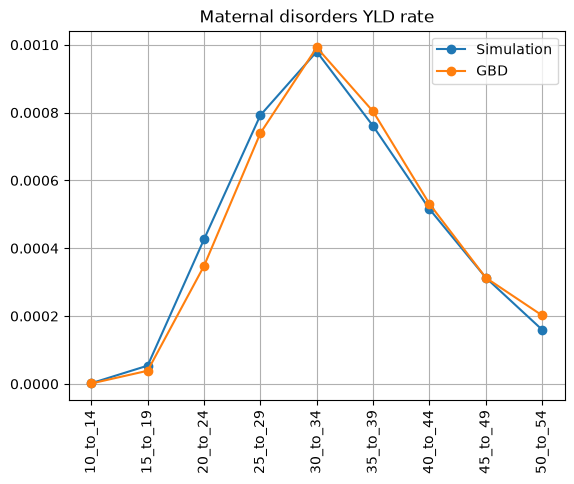

In [30]:
md_ylds = yld_rate.copy().reset_index()
md_ylds = md_ylds.loc[(md_ylds.entity=='maternal_disorders')
                     &(md_ylds.scenario=='baseline')]
plt.plot(md_ylds.reset_index().age_group, md_ylds['mean'], marker='o', label='Simulation')
plt.fill_between(md_ylds.age_group, md_ylds['2.5%'], md_ylds['97.5%'], alpha=0.3)
plt.plot(md_ylds.age_group, g['mean'], marker='o', label='GBD')
plt.fill_between(md_ylds.age_group, g['2.5%'], g['97.5%'], alpha=0.3)
#plt.semilogy()
plt.xticks(rotation=90)
plt.legend()
plt.title('Maternal disorders YLD rate')
plt.grid()

/tmp/ipykernel_3893914/2881412556.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mort_frac= (deaths.groupby(cols).sum() / births.groupby(cols).sum())[['value']]


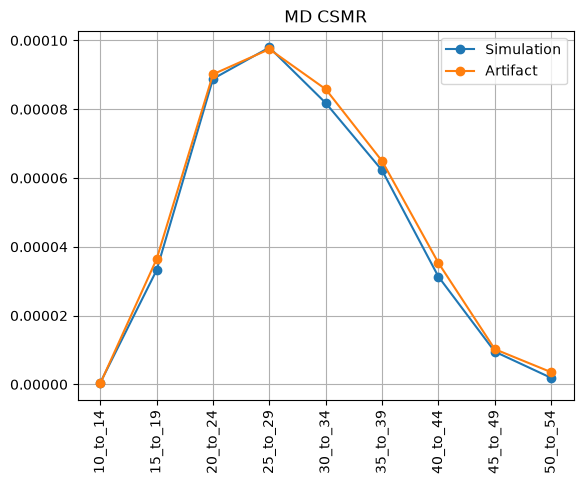

In [31]:
cols = ['scenario','input_draw','age_group']
deaths = pd.read_parquet(paths.measure_path(results_dir, "deaths"))
mort_frac= (deaths.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (mort_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_disorders.cause_specific_mortality_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in ylds.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MD CSMR')
plt.grid()
plt.legend()

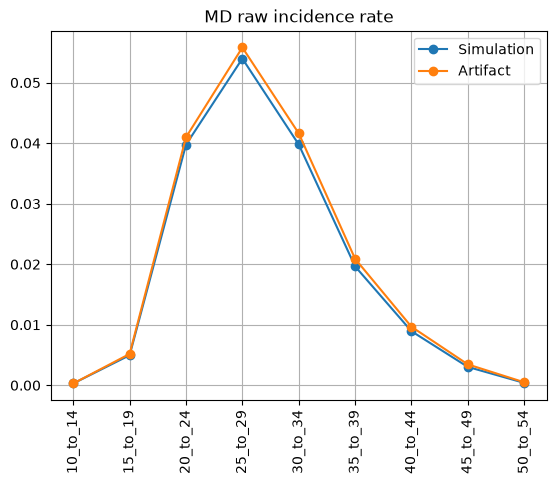

In [32]:
cols = ['scenario','input_draw','age_group']
inc_frac= (md_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (inc_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_disorders.raw_incidence_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in ylds.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MD raw incidence rate')
plt.grid()
plt.legend()

/tmp/ipykernel_3893914/3920017641.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  inc_frac= (mh_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]


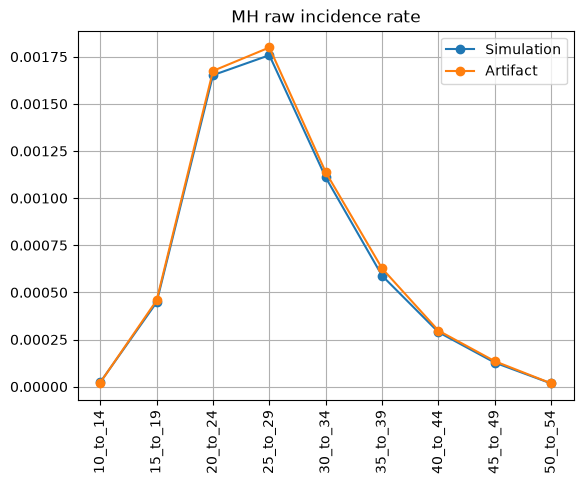

In [33]:
cols = ['scenario','input_draw','age_group']
inc_frac= (mh_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (inc_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_hemorrhage.raw_incidence_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in deaths.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MH raw incidence rate')
plt.grid()
plt.legend()

# Checking more artifact values

In [34]:
# MD anemia YLDs

x = get_draws(release_id=16,
                    year_id=YEAR_START,
                    source='como',
                    gbd_id_type='sequela_id',
                    gbd_id=[182,183,184],
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
x = x.merge(get_ids('age_group'), on='age_group_id')
x['age_start'] = x.age_group_name.str.split(' to ', expand=True)[0].astype(float)
x['age_end'] = x.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
x['sex'] = 'Female'
x['year_start'] = YEAR_START # UPDATE?
x['year_end'] = YEAR_START + 1 # UPDATE?
x = x.groupby(['sex','age_start','age_end','year_start','year_end'])[[c for c in x.columns if 'draw' in c]].sum()
x

/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


draw_0        draw_1  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2023       2024      2.360774e-07  5.332088e-08   
       15.0      20.0    2023       2024      2.670109e-06  1.255016e-06   
       20.0      25.0    2023       2024      9.399122e-06  6.607579e-06   
       25.0      30.0    2023       2024      6.379211e-06  4.767862e-06   
       30.0      35.0    2023       2024      3.170818e-06  2.099087e-06   
       35.0      40.0    2023       2024      1.739293e-06  1.114499e-06   
       40.0      45.0    2023       2024      9.186732e-07  5.970067e-07   
       45.0      50.0    2023       2024      4.542283e-07  2.907731e-07   
       50.0      55.0    2023       2024      7.358902e-08  4.385999e-08   

                                                    draw_2        draw_3  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2023       2024      9.650409e-08  2.047876e-07   
       15.0      20.0    2023       2024      1.438606e-06  5.146312e-06   
       20.0      25.0    2023       2024      5.682186e-06  1.901112e-05   
       25.0      30.0    2023       2024      7.117953e-06  1.436218e-05   
       30.0      35.0    2023       2024      4.329955e-06  7.152547e-06   
       35.0      40.0    2023       2024      2.181263e-06  3.971592e-06   
       40.0      45.0    2023       2024      8.817924e-07  1.634061e-06   
       45.0      50.0    2023       2024      4.420769e-07  7.479293e-07   
       50.0      55.0    2023       2024      6.115519e-08  1.301193e-07   

                                                    draw_4        draw_5  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2023       2024      6.599035e-08  2.001667e-08   
       15.0      20.0    2023       2024      1.698593e-06  8.681456e-07   
       20.0      25.0    2023       2024      6.284975e-06  1.809329e-06   
       25.0      30.0    2023       2024      9.033722e-06  2.130342e-06   
       30.0      35.0    2023       2024      5.159769e-06  1.678923e-06   
       35.0      40.0    2023       2024      2.016619e-06  9.515543e-07   
       40.0      45.0    2023       2024      9.903306e-07  5.333403e-07   
       45.0      50.0    2023       2024      5.039335e-07  1.928341e-07   
       50.0      55.0    2023       2024      5.942301e-08  1.934818e-08   

                                                    draw_6        draw_7  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2023       2024      3.207876e-08  8.864488e-08   
       15.0      20.0    2023       2024      3.772144e-07  1.939206e-06   
       20.0      25.0    2023       2024      1.699774e-06  5.855966e-06   
       25.0      30.0    2023       2024      1.421532e-06  7.017193e-06   
       30.0      35.0    2023       2024      9.189785e-07  4.700372e-06   
       35.0      40.0    2023       2024      4.305357e-07  3.149872e-06   
       40.0      45.0    2023       2024      2.305862e-07  1.107741e-06   
       45.0      50.0    2023       2024      1.110123e-07  3.522640e-07   
       50.0      55.0    2023       2024      2.033899e-08  5.847548e-08   

                                                    draw_8        draw_9  ...  \
sex    age_start age_end year_start year_end                              ...   
Female 10.0      15.0    2023       2024      1.457890e-08  8.811969e-08  ...   
       15.0      20.0    2023       2024      3.854608e-07  2.530935e-06  ...   
       20.0      25.0    2023       2024      1.075553e-06  6.905642e-06  ...   
       25.0      30.0    2023       2024      1.069387e-06  7.319551e-06  ...   
       30.0      35.0    2023       2024      5.886627e-07  4.980923e-06  ...   
       35.0      40.0    2023       2024      3.252331e-07  3.028657e-06  ...   
       40.0      45.0    2023       2024      1.789902e-

In [35]:
# MD YLDs prepped
y = gbd_ylds.merge(get_ids('age_group'), on='age_group_id')
y['age_start'] = y.age_group_name.str.split(' to ', expand=True)[0].astype(float)
y['age_end'] = y.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
y['sex'] = 'Female'
y['year_start'] = YEAR_START
y['year_end'] = YEAR_START + 1
y = y.set_index(['sex','age_start','age_end','year_start','year_end'])[[c for c in y.columns if 'draw' in c]]
y

draw_0    draw_1    draw_2  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2023       2024      0.000001  0.000001  0.000003   
       15.0      20.0    2023       2024      0.000041  0.000064  0.000058   
       20.0      25.0    2023       2024      0.000357  0.000379  0.000439   
       25.0      30.0    2023       2024      0.000746  0.000550  0.000650   
       30.0      35.0    2023       2024      0.000995  0.000630  0.000704   
       35.0      40.0    2023       2024      0.000805  0.000492  0.000606   
       40.0      45.0    2023       2024      0.000532  0.000427  0.000508   
       45.0      50.0    2023       2024      0.000313  0.000318  0.000329   
       50.0      55.0    2023       2024      0.000202  0.000211  0.000198   

                                                draw_3    draw_4    draw_5  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2023       2024      0.000004  0.000001  0.000002   
       15.0      20.0    2023       2024      0.000069  0.000028  0.000046   
       20.0      25.0    2023       2024      0.000452  0.000320  0.000361   
       25.0      30.0    2023       2024      0.000831  0.000710  0.000840   
       30.0      35.0    2023       2024      0.001051  0.000934  0.001320   
       35.0      40.0    2023       2024      0.000823  0.000770  0.000947   
       40.0      45.0    2023       2024      0.000491  0.000566  0.000552   
       45.0      50.0    2023       2024      0.000297  0.000383  0.000290   
       50.0      55.0    2023       2024      0.000170  0.000214  0.000172   

                                                draw_6    draw_7    draw_8  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2023       2024      0.000001  0.000002  0.000001   
       15.0      20.0    2023       2024      0.000037  0.000060  0.000064   
       20.0      25.0    2023       2024      0.000270  0.000448  0.000294   
       25.0      30.0    2023       2024      0.000493  0.000819  0.000565   
       30.0      35.0    2023       2024      0.000628  0.000920  0.000781   
       35.0      40.0    2023       2024      0.000547  0.000668  0.000744   
       40.0      45.0    2023       2024      0.000434  0.000471  0.000512   
       45.0      50.0    2023       2024      0.000294  0.000282  0.000283   
       50.0      55.0    2023       2024      0.000157  0.000166  0.000171   

                                                draw_9  ...  draw_240  \
sex    age_start age_end year_start year_end            ...             
Female 10.0      15.0    2023       2024      0.000002  ...  0.000002   
       15.0      20.0    2023       2024      0.000042  ...  0.000043   
       20.0      25.0    2023       2024      0.000396  ...  0.000440   
       25.0      30.0    2023       2024      0.000760  ...  0.000820   
       30.0      35.0    2023       2024      0.000898  ...  0.001161   
       35.0      40.0    2023       2024      0.000631  ...  0.001046   
       40.0      45.0    2023       2024      0.000367  ...  0.000761   
       45.0      50.0    2023       2024      0.000231  ...  0.000538   
       50.0      55.0    2023       2024      0.000127  ...  0.000268   

                                              draw_241  draw_242  draw_243  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2023       2024      0.000003  0.000002  0.000002   
       15.0      20.0    2023       2024      0.000061  0.000070  0.000043   
       20.0      25.0    2023       2024      0.000371  0.000491  0.000373   
       25.0      30.0    2023       2024      0.000676  0.000945  0.000870   
       30.0      35.0    2023       2024      0.000801  0.001133  0.001231   
       35.0      40.0    2023       2024      0.000677  0.000935  0.000920   
       40.0      45.0    2023       2024   

In [36]:
calculated_ylds  = ((y-x)/( art.load('cause.maternal_disorders.raw_incidence_rate') - art.load('cause.maternal_disorders.cause_specific_mortality_rate'))).mean(axis=1).reset_index()
calculated_ylds

,sex,age_start,age_end,year_start,year_end,0
0,Female,10.0,15.0,2023,2024,0.003986
1,Female,15.0,20.0,2023,2024,0.007533
2,Female,20.0,25.0,2023,2024,0.008502
3,Female,25.0,30.0,2023,2024,0.013269
4,Female,30.0,35.0,2023,2024,0.023884
5,Female,35.0,40.0,2023,2024,0.038561
6,Female,40.0,45.0,2023,2024,0.055088
7,Female,45.0,50.0,2023,2024,0.090911
8,Female,50.0,55.0,2023,2024,0.408924
9,Female,55.0,60.0,2023,2024,NaN


In [37]:
art_ylds = art.load('cause.maternal_disorders.ylds')
art_ylds = art_ylds.mean(axis=1).reset_index()
art_ylds

,sex,age_start,age_end,year_start,year_end,0
0,Female,10.0,15.0,2023,2024,0.006489
1,Female,15.0,20.0,2023,2024,0.011016
2,Female,20.0,25.0,2023,2024,0.010787
3,Female,25.0,30.0,2023,2024,0.014704
4,Female,30.0,35.0,2023,2024,0.024628
5,Female,35.0,40.0,2023,2024,0.038694
6,Female,40.0,45.0,2023,2024,0.057709
7,Female,45.0,50.0,2023,2024,0.103043
8,Female,50.0,55.0,2023,2024,0.398153
9,Female,55.0,60.0,2023,2024,0.203931


Text(0.5, 1.0, 'Maternal disorders YLDs per non-fatal case')

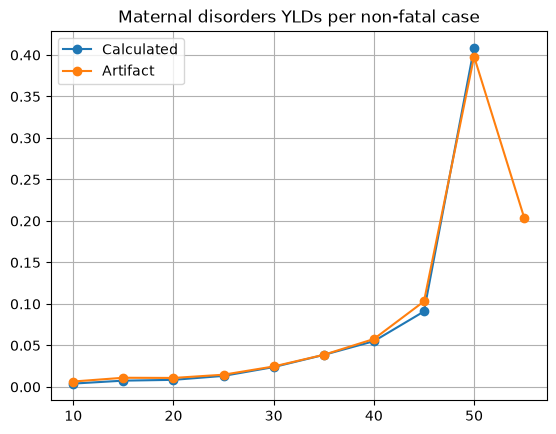

In [38]:
plt.plot(calculated_ylds.age_start, calculated_ylds[0], marker='o', label='Calculated')
plt.plot(art_ylds.age_start, art_ylds[0], marker='o', label='Artifact')
plt.legend()
#plt.semilogy()
plt.grid()
plt.title('Maternal disorders YLDs per non-fatal case')

In [39]:
gbd_csmr = get_outputs(release_id=16,
                    year_id=YEAR_START,
                    sex_id=2,
                    age_group_id=list(range(7,17)),
                    topic='cause',
                    cause_id=366,
                    measure_id=1,
                    metric_id=3,
                    location_id=location_id,
                    #compare_version_id=7948
                      )
gbd_csmr

,age_group_id,cause_id,location_id,measure_id,metric_id,sex_id,year_id,acause,age_group_name,cause_name,expected,location_name,location_type,measure,measure_name,metric_name,sex,val,upper,lower
0,7,366,163,1,3,2,2023,maternal,10 to 14,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,2.585859e-07,4.349916e-07,1.465869e-07
1,8,366,163,1,3,2,2023,maternal,15 to 19,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,3.643736e-05,5.071968e-05,2.513309e-05
2,9,366,163,1,3,2,2023,maternal,20 to 24,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,9.016579e-05,1.189286e-04,6.371979e-05
3,10,366,163,1,3,2,2023,maternal,25 to 29,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,9.747169e-05,1.359892e-04,6.973921e-05
4,11,366,163,1,3,2,2023,maternal,30 to 34,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,8.582643e-05,1.173461e-04,6.278324e-05
5,12,366,163,1,3,2,2023,maternal,35 to 39,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,6.492597e-05,9.234054e-05,4.618935e-05
6,13,366,163,1,3,2,2023,maternal,40 to 44,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,3.530094e-05,4.874374e-05,2.364929e-05
7,14,366,163,1,3,2,2023,maternal,45 to 49,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,1.022782e-05,1.470333e-05,7.271748e-06
8,15,366,163,1,3,2,2023,maternal,50 to 54,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,3.540845e-06,5.522513e-06,2.136104e-06
9,16,366,163,1,3,2,2023,maternal,55 to 59,Maternal disorders,NaN,India,admin0,death,Deaths,Rate,Female,NaN,NaN,NaN


Text(0.5, 1.0, 'MD CSMR')

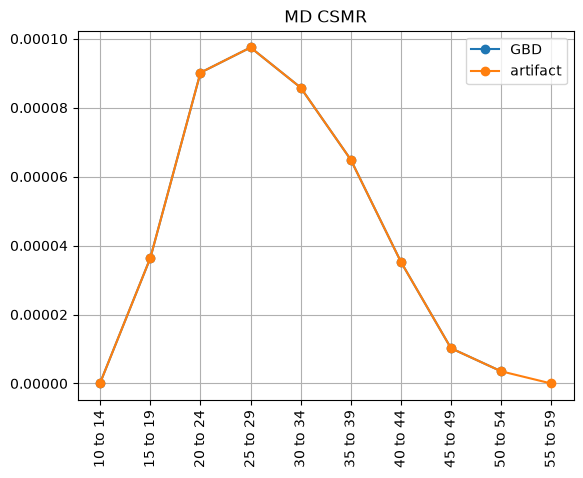

In [40]:
plt.plot(gbd_csmr.age_group_name, gbd_csmr.val, marker='o', label='GBD')
plt.plot(gbd_csmr.age_group_name, art.load('cause.maternal_disorders.cause_specific_mortality_rate').mean(axis=1),
        marker='o', label="artifact")
plt.grid()
plt.xticks(rotation=90)
plt.legend()
plt.title('MD CSMR')

    # These used to exactly replicate eachother... double check year_ids

In [41]:
anemia_pt = pd.read_parquet(paths.measure_path(results_dir, "person_time_anemia"))
anemia_pt = anemia_pt.loc[anemia_pt.scenario=='baseline']
anemia_pt.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,person_time,impairment,anemia,not_anemic,10_to_14,invalid,1,baseline,0,141,5.691992
1,person_time,impairment,anemia,not_anemic,10_to_14,invalid,2,baseline,0,141,1.954825
2,person_time,impairment,anemia,not_anemic,10_to_14,invalid,3,baseline,0,141,3.622177
3,person_time,impairment,anemia,not_anemic,10_to_14,invalid,4,baseline,0,141,4.427105
4,person_time,impairment,anemia,not_anemic,10_to_14,invalid,5,baseline,0,141,3.488022


In [42]:
(anemia_pt.groupby(['scenario','sub_entity'])['value'].sum() 
 / anemia_pt.groupby(['scenario'])['value'].sum()).reset_index().sort_values(by='sub_entity').dropna()

,scenario,sub_entity,value
0,baseline,not_anemic,0.519759
1,baseline,mild,0.206564
2,baseline,moderate,0.251660
3,baseline,severe,0.022017


In [43]:
cols = ['input_draw','scenario','age_group']
anemia = (anemia_pt.groupby(cols + ['sub_entity'])['value'].sum() 
          / anemia_pt.groupby(cols)['value'].sum()).reset_index().dropna()
anemia = (anemia.groupby([c for c in cols if c != 'input_draw'] + ['sub_entity'])
          ['value'].describe(percentiles=[0.025,0.975]).reset_index())
anemia.head()

,scenario,age_group,sub_entity,count,mean,std,min,2.5%,50%,97.5%,max
0,baseline,10_to_14,not_anemic,1.0,0.424198,NaN,0.424198,0.424198,0.424198,0.424198,0.424198
1,baseline,10_to_14,mild,1.0,0.109966,NaN,0.109966,0.109966,0.109966,0.109966,0.109966
2,baseline,10_to_14,moderate,1.0,0.403822,NaN,0.403822,0.403822,0.403822,0.403822,0.403822
3,baseline,10_to_14,severe,1.0,0.062014,NaN,0.062014,0.062014,0.062014,0.062014,0.062014
4,baseline,15_to_19,not_anemic,1.0,0.506470,NaN,0.506470,0.506470,0.506470,0.506470,0.506470


In [44]:
target =get_draws(
        gbd_id_type='rei_id',
        gbd_id=[205, 206, 207], # Mild, moderate, and severe anemia, respectively. We also have rei_id=192 for all anemia and rei_id=432 for moderate and severe combined
        location_id=location_id,
        population_group_id=16, # pregnant population
        sex_id=2, # female
        year_id=2023,
        release_id=33, # GBD 2023, special publications
        source='como',
        measure_id=[5,3], # prevalence
        metric_id=3, # rate
        age_group_id=[7, 8, 9, 10, 11, 12, 13, 14, 15], # constituent age groups of 10-54 years (169)
    )
target.head()

/mnt/team/simulation_science/priv/engineering/jenkins/shared_envs/vivarium_gates_lsff_2026_artifact_current/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


,age_group_id,cause_id,draw_0,draw_1,draw_10,draw_11,draw_12,draw_13,draw_14,draw_15,...,draw_98,draw_99,location_id,measure_id,population_group_id,rei_id,sex_id,year_id,metric_id,version_id
0,7,294,3.945793e-01,2.202881e-01,0.292629,0.177105,1.353744e-01,1.969261e-01,2.086699e-01,1.741766e-01,...,0.221329,1.756899e-01,163,5,16,205,2,2023,3,1773
1,7,295,3.720658e-01,2.072972e-01,0.277731,0.167506,1.285873e-01,1.871061e-01,1.981404e-01,1.651333e-01,...,0.207023,1.672175e-01,163,5,16,205,2,2023,3,1773
2,7,298,8.627158e-07,1.080694e-06,0.000001,0.000001,5.412338e-07,8.840512e-07,7.218272e-07,7.054266e-07,...,0.000002,4.543730e-07,163,5,16,205,2,2023,3,1773
3,7,300,7.866712e-07,9.984694e-07,0.000001,0.000001,5.000127e-07,8.301703e-07,6.800916e-07,6.547092e-07,...,0.000002,4.264038e-07,163,5,16,205,2,2023,3,1773
4,7,344,3.712301e-02,2.051935e-02,0.027868,0.016854,1.285184e-02,1.863539e-02,1.986870e-02,1.655211e-02,...,0.020515,1.675515e-02,163,5,16,205,2,2023,3,1773


In [45]:
#Had to do some manual adjustments to make the draw list include all the modulo ones.  

print(anemia_pt.input_draw.unique())
draw_list = [3, 41, 21, 13, 39, 16, 99, 77, 8, 92]
draw_list

[0]


[3, 41, 21, 13, 39, 16, 99, 77, 8, 92]

In [46]:
target_test = target.copy()
target_test["severity"] = target_test["rei_id"].map({205: "mild",206: "moderate",207: "severe"})
target_test = target_test.merge(get_ids('age_group'), on='age_group_id')
target_test['age_group'] = target_test.age_group_name.str.replace(' ', '_')
target_test=target_test.loc[(target_test.cause_id==294)]
target_test = target_test[[c for c in target_test.columns if not c.startswith("draw_")] +[f"draw_{x}" for x in draw_list if f"draw_{x}" in target_test.columns]]
draw_cols = [c for c in target_test.columns if c.startswith("draw_")]
id_cols = [c for c in target_test.columns if not c.startswith("draw_")]
target_test = target_test.melt(id_vars=id_cols,value_vars=draw_cols,var_name="draw",value_name="value")
target_prev = target_test.loc[target_test.measure_id==5]
target_ylds = target_test.loc[target_test.measure_id==3]
target_prev = target_prev.groupby(['age_group','severity'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
target_ylds = target_ylds.groupby(['age_group','draw']).value.sum().groupby('age_group').describe(percentiles=[0.025,0.975]).reset_index()
target_prev.head()

,age_group,severity,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,mild,10.0,0.214631,0.068579,0.122094,0.131014,0.203471,0.347128,0.372930
1,10_to_14,moderate,10.0,0.268349,0.043463,0.201702,0.206516,0.269676,0.336175,0.342034
2,10_to_14,severe,10.0,0.033963,0.018182,0.008345,0.010982,0.035190,0.068032,0.075449
3,15_to_19,mild,10.0,0.230980,0.043894,0.169786,0.173744,0.223295,0.315724,0.331721
4,15_to_19,moderate,10.0,0.288077,0.014485,0.265687,0.267345,0.284579,0.310365,0.310682


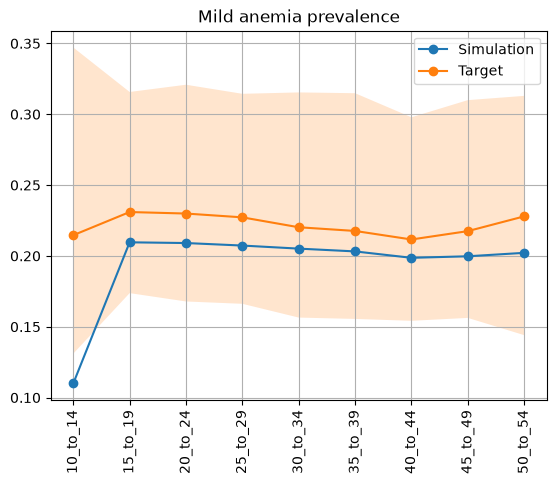

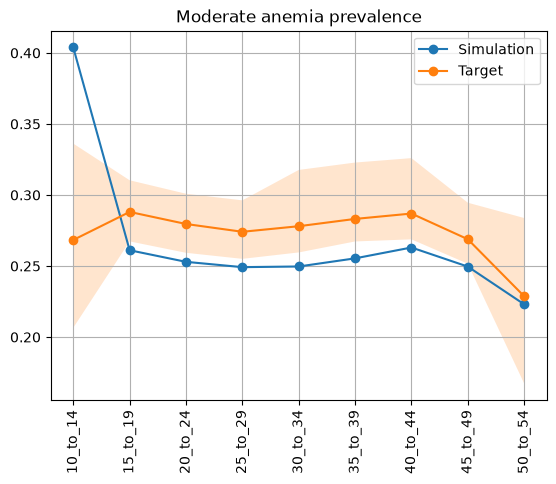

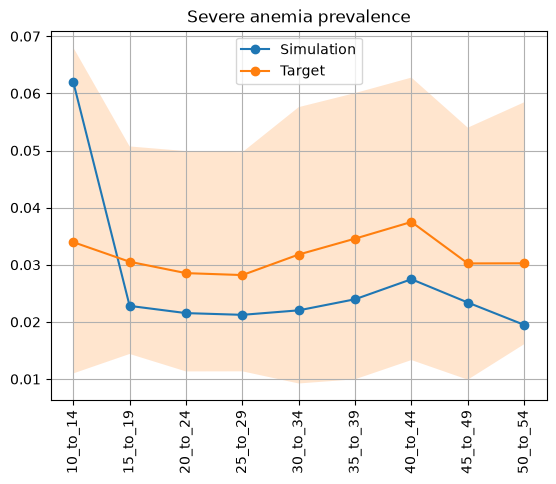

In [47]:
for sev in ['mild','moderate','severe']:
    s = anemia.loc[anemia.sub_entity==sev]
    plt.plot(s.age_group, s['mean'], marker='o', label='Simulation')
    plt.fill_between(s.age_group, s['2.5%'], s['97.5%'], alpha=0.2)
    t = target_prev.loc[target_prev.severity==sev]
    plt.plot(t.age_group, t['mean'], marker='o', label='Target')
    plt.fill_between(t.age_group, t['2.5%'], t['97.5%'], alpha=0.2)
    plt.grid()
    plt.legend()
    plt.xticks(rotation=90)
    plt.title(f'{sev.title()} anemia prevalence')
    plt.show()

In [48]:
# NOTE: the target and the output are a bit of a mismatch here. I updates to the new target code that is for GBD 2023, but the 
# artifact was made with the old version of hemoglobin. Some mismatch is expected. 
# This should resolve with the GBD 2023 version. If it does not, then it's a problem! 

In [49]:
anemia_ylds = ylds.loc[(ylds.sub_entity=='anemia')&(ylds.scenario=='baseline')]
pt = pd.read_parquet(paths.measure_path(results_dir, "person_time_pregnancy"))
pt = pt.loc[pt.scenario=='baseline']
anemia_ylds = (anemia_ylds.groupby(['input_draw','age_group']).sum()[['value']] 
               / pt.groupby(['input_draw','age_group']).sum()[['value']]
               #* (52/36)
              )
anemia_ylds = anemia_ylds.groupby(['age_group']).value.describe(percentiles=[0.025,0.975]).reset_index()
anemia_ylds = anemia_ylds.fillna(0)
anemia_ylds

/tmp/ipykernel_3893914/3857979932.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  anemia_ylds = (anemia_ylds.groupby(['input_draw','age_group']).sum()[['value']]
/tmp/ipykernel_3893914/3857979932.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  / pt.groupby(['input_draw','age_group']).sum()[['value']]


,age_group,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,1.0,0.030030,0.0,0.030030,0.030030,0.030030,0.030030,0.030030
1,15_to_19,1.0,0.017432,0.0,0.017432,0.017432,0.017432,0.017432,0.017432
2,20_to_24,1.0,0.016813,0.0,0.016813,0.016813,0.016813,0.016813,0.016813
3,25_to_29,1.0,0.016550,0.0,0.016550,0.016550,0.016550,0.016550,0.016550
4,30_to_34,1.0,0.016666,0.0,0.016666,0.016666,0.016666,0.016666,0.016666
5,35_to_39,1.0,0.017217,0.0,0.017217,0.017217,0.017217,0.017217,0.017217
6,40_to_44,1.0,0.018076,0.0,0.018076,0.018076,0.018076,0.018076,0.018076
7,45_to_49,1.0,0.016778,0.0,0.016778,0.016778,0.016778,0.016778,0.016778
8,50_to_54,1.0,0.014803,0.0,0.014803,0.014803,0.014803,0.014803,0.014803
9,55_to_59,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Anemia YLD rate')

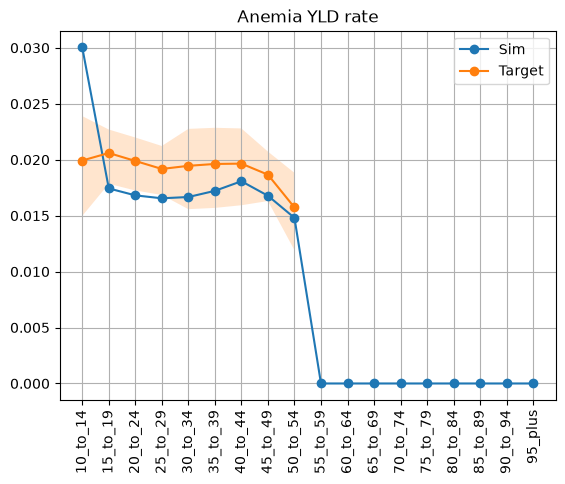

In [50]:
plt.plot(anemia_ylds.age_group, anemia_ylds['mean'], marker='o', label='Sim')
plt.fill_between(anemia_ylds.age_group, anemia_ylds['2.5%'], anemia_ylds['97.5%'], alpha=0.2)
plt.plot(target_ylds.age_group, target_ylds['mean'], marker='o', label='Target')
plt.fill_between(target_ylds.age_group, target_ylds['2.5%'], target_ylds['97.5%'], alpha=0.2)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
#plt.ylim(ymax=0.05)
plt.title('Anemia YLD rate')

# ok this used to be meeting target in model 12.0 but looks off here

In [51]:
# Same here! The GBD rounds are not aligned. Confirm that this is fixed in the GBD 2023 version 

## Added V&V: sim anemia severity vs the artifact's own hemoglobin distribution

If the sim faithfully samples the artifact hemoglobin distribution, its severity shares must
equal the artifact-implied shares (ensemble CDF at the pregnancy thresholds, averaged over
wealth quintiles). Read together with the GBD-target panels above:
- sim ≈ artifact-implied, but both ≠ target → threshold / target-side issue
- sim ≠ artifact-implied → sim-side issue

In [52]:
from lsff_utils.hemoglobin_distribution import hemoglobin_cdf_from_mean_sd

# pregnancy anemia thresholds used by the sim (0200 constants/data_values.py):
# (severe_upper, moderate_upper, mild_upper); ages 10-14 use the 5-15 row
def cutoffs(age_start):
    return (80, 110, 115) if age_start < 15 else (70, 100, 110)

hgb_m = art.load("risk_factor.hemoglobin.mean")["draw_0"].groupby(["age_start", "wealth_quintile"]).mean()
hgb_s = art.load("risk_factor.hemoglobin.standard_deviation")["draw_0"].groupby(["age_start", "wealth_quintile"]).mean()

implied = []
for idx in hgb_m.index:
    if hgb_m[idx] <= 0:
        continue
    cdf = hemoglobin_cdf_from_mean_sd(hgb_m[idx], hgb_s[idx])
    sev, mod, mild = cutoffs(idx[0])
    c_sev, c_mod, c_mild = float(cdf(sev)), float(cdf(mod)), float(cdf(mild))
    implied.append((idx[0], c_sev, c_mod - c_sev, c_mild - c_mod))
implied = (
    pd.DataFrame(implied, columns=["age_start", "severe", "moderate", "mild"])
    .groupby("age_start").mean()  # quintiles are equal fifths
    .assign(age_group=lambda df: df.index.map(lambda a: f"{int(a)}_to_{int(a) + 4}"))
)
implied

,severe,moderate,mild,age_group
age_start,,,,
10.0,0.060088,0.427881,0.114890,10_to_14
15.0,0.025165,0.276517,0.214586,15_to_19
20.0,0.023286,0.268350,0.214717,20_to_24
25.0,0.022933,0.264132,0.212845,25_to_29
30.0,0.023775,0.265619,0.211195,30_to_34
35.0,0.026207,0.272132,0.208542,35_to_39
40.0,0.029296,0.277423,0.204050,40_to_44
45.0,0.025461,0.263720,0.204765,45_to_49
50.0,0.020966,0.246826,0.206723,50_to_54


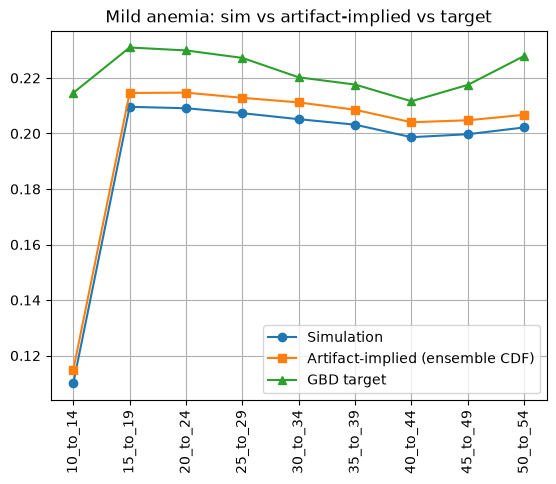

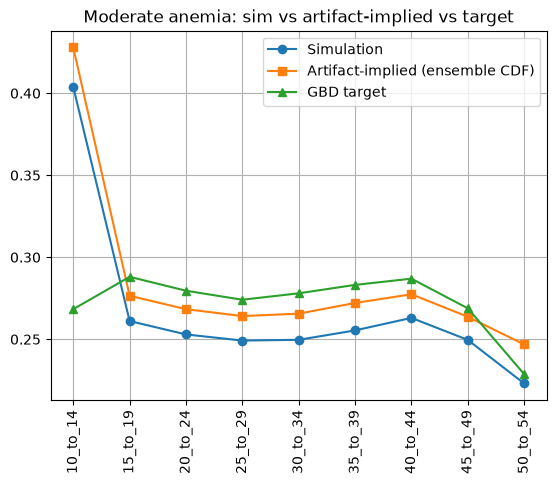

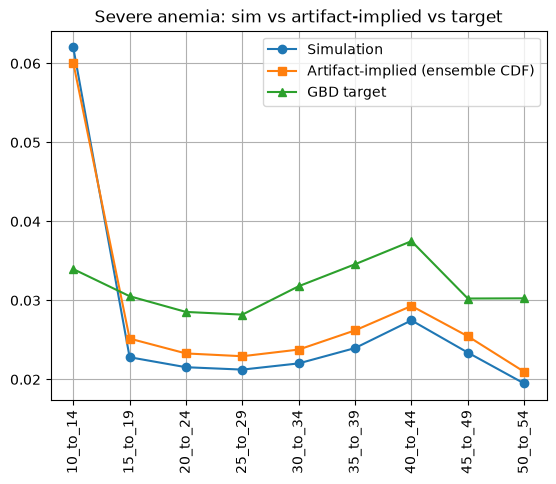

In [53]:
for sev in ["mild", "moderate", "severe"]:
    s = anemia.loc[anemia.sub_entity == sev]
    plt.plot(s.age_group, s["mean"], marker="o", label="Simulation")
    plt.plot(implied.age_group, implied[sev], marker="s", label="Artifact-implied (ensemble CDF)")
    t = target_prev.loc[target_prev.severity == sev]
    plt.plot(t.age_group, t["mean"], marker="^", label="GBD target")
    plt.xticks(rotation=90); plt.grid(); plt.legend()
    plt.title(f"{sev.title()} anemia: sim vs artifact-implied vs target")
    plt.show()

## Added V&V: scenario impacts vs first-principles expectation

Expected anemia impact (pp) ≈ hemoglobin effect (g/L) × Δ effective coverage × density at the
mild threshold. Expected MD relative change ≈ Δ effective coverage × (1 − RR^(−effect/10)),
damped in practice by the per-simulant probability clip at high incident fractions.
Catches coverage-wiring bugs (double-counted coverage, saturation) at a glance.
NOTE: under the fixed-shift parameterization the effect is the vehicle's trial-mean
difference; if the dose-response branch lands, effect = 0.194 g/L per mg/day × delivered
dose, and these expectations shrink 2–7×.

In [54]:
from lsff_utils.hemoglobin_distribution import hemoglobin_pdf_from_mean_sd


apt = pd.read_parquet(paths.measure_path(results_dir, "person_time_anemia"))
prev = (
    apt[apt.sub_entity.isin(["mild", "moderate", "severe"])].groupby("scenario").value.sum()
    / apt.groupby("scenario").value.sum()
)

# the sim's intervention only expands coverage where target exceeds baseline
def qmean(key):
    return float(art.load(key).value.mean())

target_cov = qmean("iron_fortification.intervention_coverage") * qmean("vehicle_consumption.fortifiability")
base_cov = qmean("iron_fortification.baseline_any_coverage")
delta_cov = (
    qmean("vehicle_consumption.any_consumed")
    * max(0.0, target_cov - base_cov)
    * qmean("iron_fortification.intervention_effectiveness")
)
effect = float(
    art.load("iron_fortification.hemoglobin_effect_size").reset_index()
    .set_index("vehicle_name").value.loc[vehicle]
)
mild_cut = 110.0
density = float(np.mean([
    hemoglobin_pdf_from_mean_sd(hgb_m[i], hgb_s[i])(mild_cut) for i in hgb_m.index if hgb_m[i] > 0
]))
print(f"anemia prevalence by scenario:\n{prev.round(4).to_string()}")
print(f"observed intervention-baseline: {(prev['intervention'] - prev['baseline']) * 100:+.2f} pp")
print(f"expected ≈ {-effect * delta_cov * density * 100:.2f} pp "
      f"(effect {effect} g/L × Δcov {delta_cov:.3f} × density {density:.4f}/g/L)")

anemia prevalence by scenario:
scenario
baseline        0.4802
intervention    0.4802
zero            0.5109
observed intervention-baseline: +0.00 pp
expected ≈ -0.00 pp (effect 3.25 g/L × Δcov 0.000 × density 0.0230/g/L)


In [55]:
md_t = pd.read_parquet(paths.measure_path(results_dir, "transition_count_maternal_disorders"))
md_t = md_t[md_t.sub_entity == "susceptible_to_maternal_disorders_to_maternal_disorders"]
dth = pd.read_parquet(paths.measure_path(results_dir, "deaths"))
dth = dth[dth.entity == "maternal_disorders"]
brt = pd.read_parquet(paths.measure_path(results_dir, "transition_count_pregnancy"))
brt = brt[brt.sub_entity == "pregnant_to_parturition"]
md_frac = (md_t.groupby("scenario").value.sum() + dth.groupby("scenario").value.sum()) / (
    brt.groupby("scenario").value.sum() + dth.groupby("scenario").value.sum()
)
rr = float(art.load("risk_factor.hemoglobin_on_maternal_disorder.relative_risk").iloc[0, 0])
print(f"MD incident fraction by scenario:\n{md_frac.round(4).to_string()}")
print(f"observed intervention/baseline - 1: {(md_frac['intervention'] / md_frac['baseline'] - 1) * 100:+.2f}%")
print(f"expected ≈ {-delta_cov * (1 - rr ** (-effect / 10)) * 100:.2f}% "
      f"(RR {rr:.3f}; clip typically damps the realized effect to ~60% of this)")

MD incident fraction by scenario:
scenario
baseline        0.4223
intervention    0.4223
zero            0.4320
observed intervention/baseline - 1: +0.00%
expected ≈ -0.00% (RR 1.253; clip typically damps the realized effect to ~60% of this)
